<a href="https://colab.research.google.com/github/Sugandha-B/SB_Data_Analysis_01/blob/main/Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploratory Data Analysis of Zomato Dataset downloaded from Kaggle.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

%matplotlib inline

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Zomato-data-.csv to Zomato-data-.csv


In [3]:
df = pd.read_csv("Zomato-data-.csv")

In [4]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [5]:
df.tail()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining
147,Vijayalakshmi,Yes,No,3.9/5,47,200,Dining


In [6]:
df.sample(5)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
124,Kwality Wall's Swirl's Happiness Station,No,No,2.9/5,25,200,Dining
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
137,Hotel Andhra Speices,No,No,2.9/5,0,250,Dining
46,Kitchen Garden,Yes,No,3.6/5,244,300,Dining
119,K27 - The Pub,No,No,3.1/5,30,900,Dining


In [7]:
df.shape

(148, 7)

In [8]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [10]:
df.describe(include='object')

,name,online_order,book_table,rate,listed_in(type)
count,148,148,148,148,148
unique,145,2,2,20,4
top,San Churro Cafe,No,No,3.8/5,Dining
freq,2,90,140,19,110


In [12]:
df.isnull().sum()


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.nunique()

,0
name,145
online_order,2
book_table,2
rate,20
votes,90
approx_cost(for two people),18
listed_in(type),4


In [16]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5'],
      dtype=object)

In [17]:
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']

df['rate'] = df['rate'].str.replace('/5','')

df['rate'] = pd.to_numeric(df['rate'])

In [18]:
df['approx_cost(for two people)'].unique()

array([800, 300, 600, 700, 550, 500, 450, 650, 400, 900, 200, 750, 150,
       850, 100, 350, 250, 950])

In [19]:
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Text(0.5, 0, 'Type of restaurant')

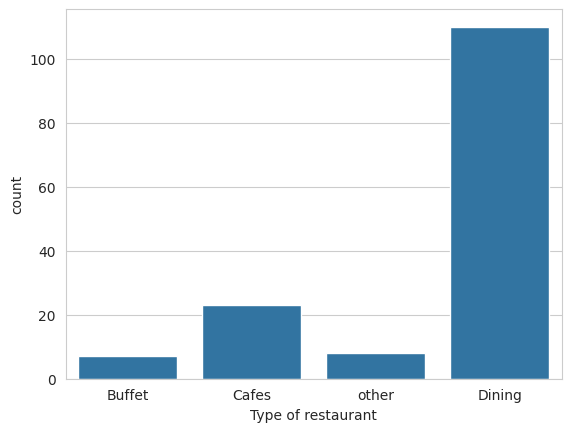

In [29]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Type of restaurant")

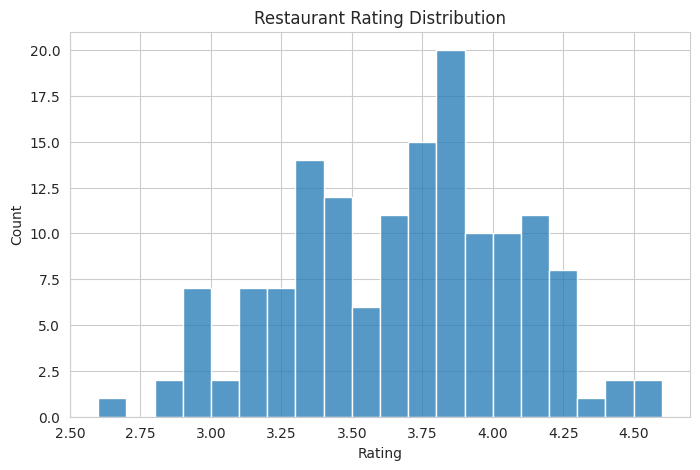

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['rate'], bins=20)

plt.title("Restaurant Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

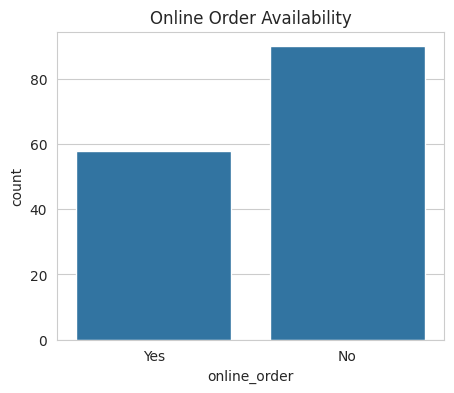

In [22]:
plt.figure(figsize=(5,4))

sns.countplot(x='online_order', data=df)

plt.title("Online Order Availability")

plt.show()

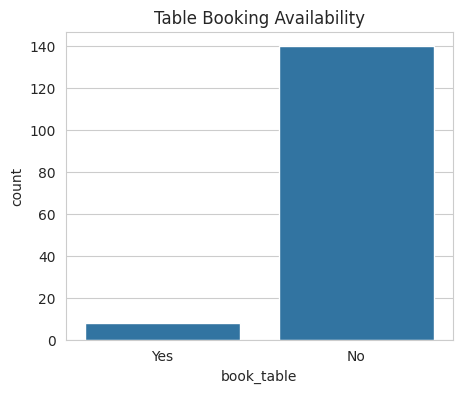

In [23]:
plt.figure(figsize=(5,4))

sns.countplot(x='book_table', data=df)

plt.title("Table Booking Availability")

plt.show()

Text(0, 0.5, 'Votes')

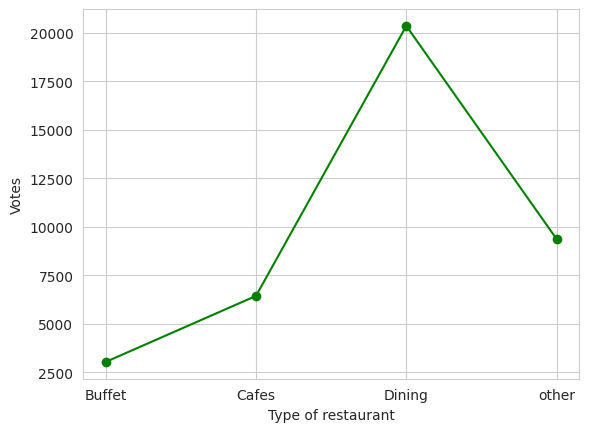

In [30]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')

In [31]:
max_votes = df['votes'].max()
restaurant_with_max_votes = df.loc[df['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


<Axes: xlabel='online_order', ylabel='count'>

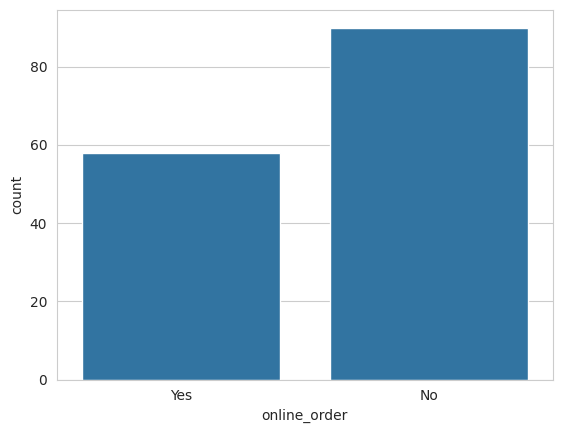

In [33]:
sns.countplot(x=df['online_order'])

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

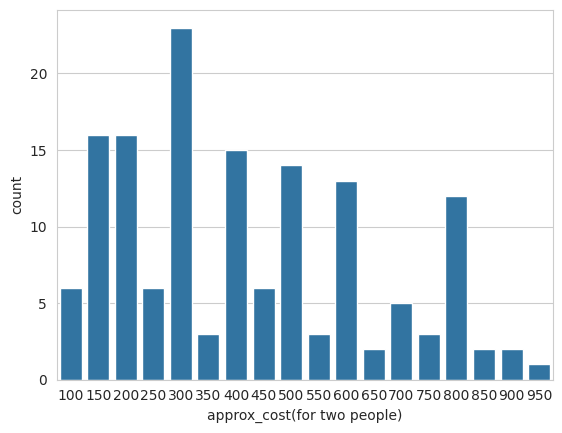

In [34]:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data)

<Axes: xlabel='online_order', ylabel='rate'>

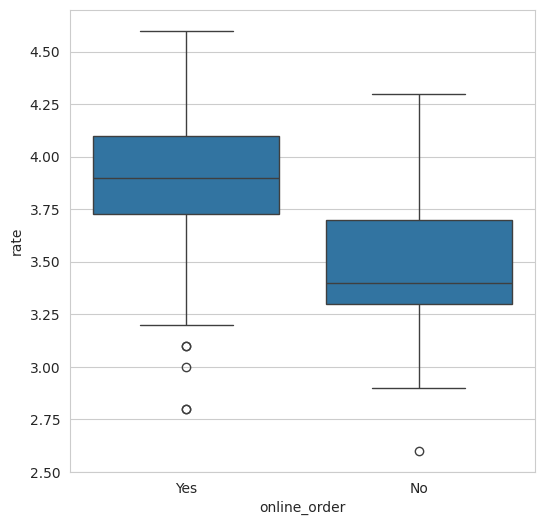

In [35]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)

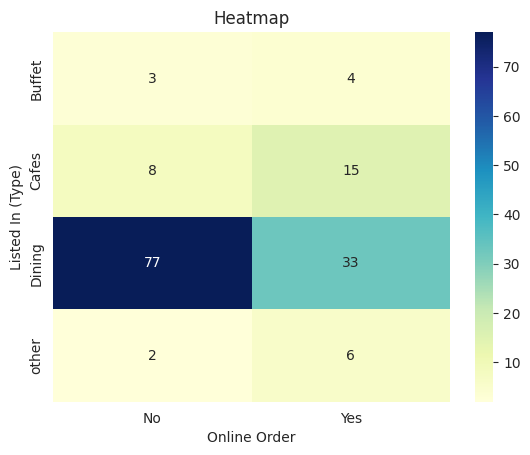

In [36]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

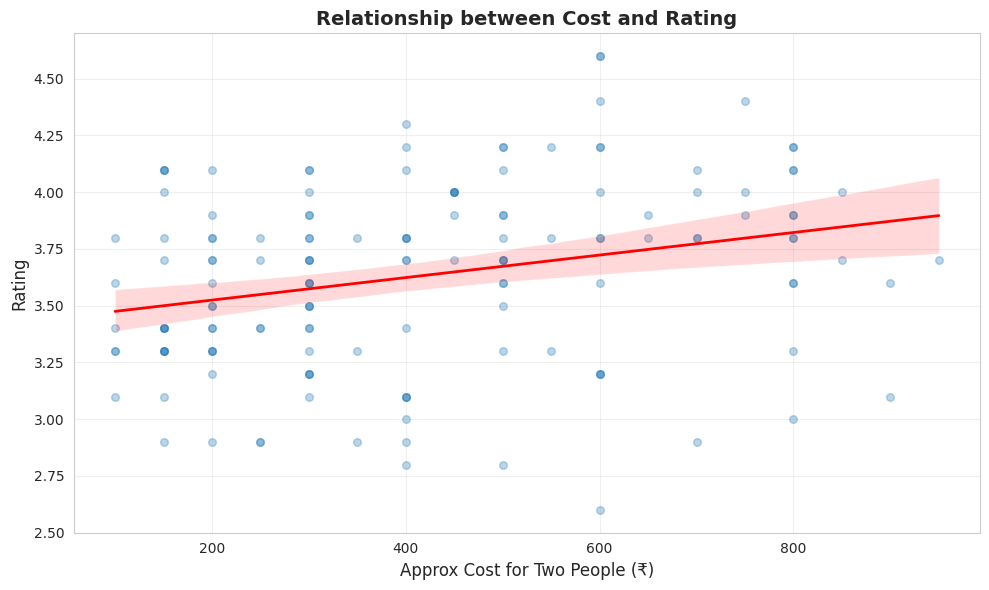

In [40]:
plt.figure(figsize=(10,6))

# Use regplot with transparency to see density
sns.regplot(x='approx_cost(for two people)', y='rate', data=df,
            scatter_kws={'alpha':0.3, 's':30},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title("Relationship between Cost and Rating", fontsize=14, fontweight='bold')
plt.xlabel("Approx Cost for Two People (₹)", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The majority of restaurants had ratings between 3.5 and 4.2. North Indian cuisine appeared most frequently. Restaurants with a higher number of votes generally tended to have better ratings. Online ordering was supported by a large proportion of restaurants. Mid-range restaurants were more common than high-end restaurants.
